In [13]:
import os
import numpy as np
import torch
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.pyplot as plt
from gaussian_blur import GaussianBlurOp
from utils import load_dataset, compute_psnr, compute_ssim
from lpn_mnist import LPN

DEVICE = "cuda"
NOISE_SIGMA = .2
BLUR_SIGMA = 1
BLUR_KERNEL_SIZE = 3
MODEL_PATH = "model.pt"
LPN_HIDDEN_LAYERS = 64
LPN_BETA = 10
LPN_NUM_CHANNELS = 1
NUMBER_TEST_IMAGES = 1
NUM_ITERATIONS = 100


In [14]:
test_ds = load_dataset("test")
idx = [105]
clean_imgs, blurry_imgs, blurry_noisy_imgs, denoised_imgs, subgradients = [], [], [], [], []

blur_op = GaussianBlurOp(channels=1, size=BLUR_KERNEL_SIZE, sigma = BLUR_SIGMA, device=DEVICE)
model = LPN(in_dim=LPN_NUM_CHANNELS, hidden=LPN_HIDDEN_LAYERS, beta=LPN_BETA).to(DEVICE)
# weights_only=True is safer; if it fails, drop that arg.
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
state = ckpt["model_state_dict"]
model.load_state_dict(state)
model.eval()
# model = ProxL2(mu=1)
torch.set_grad_enabled(False)



dataset loaded: test


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [15]:
def apply_mmse(xk):
    if isinstance(xk, torch.Tensor):
        x_torch = xk.detach().float()
    else:
        x_torch = torch.tensor(np.array(xk), dtype=torch.float32)

    x_torch = x_torch.squeeze().unsqueeze(0).unsqueeze(0).cuda()
    result = model(x_torch)
    return result.squeeze().unsqueeze(0).unsqueeze(0).detach()  # stays on CUDA

In [19]:
item  = test_ds[6]
clean = item["image"].unsqueeze(0).to(DEVICE)
blurry = blur_op.A(clean)
blurry_noisy = (blurry + 1* torch.randn_like(clean))
y = blurry_noisy
xk = blurry_noisy
grad_list = []
diff_list = []
for j in tqdm(range(NUM_ITERATIONS)):
    lastxk = xk
    xk = apply_mmse(xk - blur_op.A(blur_op.A(xk) - y))
    last_fgrad = blur_op.A(blur_op.A(lastxk) - y)
    next_fgrad = blur_op.A(blur_op.A(xk) - y)
    Fgrad = lastxk - xk + next_fgrad - last_fgrad
    grad_list.append(np.linalg.norm(Fgrad.cpu().numpy()))
    diff_list.append(np.linalg.norm(xk.cpu() - lastxk.cpu()))

100%|██████████| 100/100 [00:00<00:00, 312.51it/s]


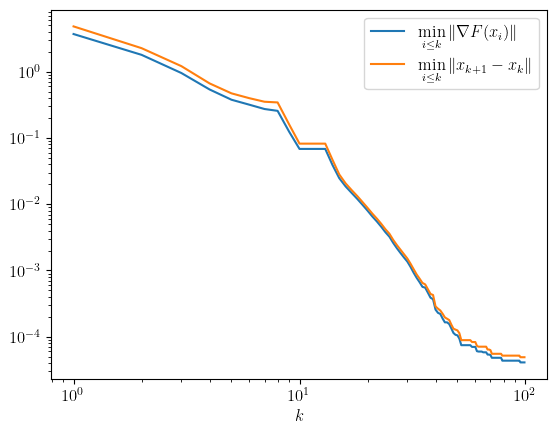

In [36]:
plt.style.use('default')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.loglog([i for i in range(1,NUM_ITERATIONS)], np.minimum.accumulate(grad_list)[1::], label="$\displaystyle \min_{i \leq k} \| \\nabla F(x_i)\|$")
plt.loglog([i for i in range(1,NUM_ITERATIONS)], np.minimum.accumulate(diff_list)[1::], label = "$\displaystyle \min_{i \leq k} \|x_{k+1}-x_k\|$")
plt.xlabel("$k$", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc="upper right",fontsize=12)
plt.savefig("mnist_subgradient.pdf", format="pdf")

In [25]:
NUM_ITERATIONS = 100
clean_imgs   = [test_ds[i]["image"].unsqueeze(0).to(DEVICE) for i in range(3)]
blurry_imgs  = [blur_op.A(clean) for clean in clean_imgs]
blurry_noisy = [blurry + .2 * torch.randn_like(blurry) for blurry in blurry_imgs]

denoised = []
for y in blurry_noisy:
    xk = y.clone()
    for j in tqdm(range(NUM_ITERATIONS)):
        xk = apply_mmse(xk - blur_op.A(blur_op.A(xk) - y))
    denoised.append(xk.detach().squeeze().cpu())

100%|██████████| 100/100 [00:00<00:00, 466.57it/s]


In [27]:
from importlib import reload
import utils
reload(utils)
from utils import show_and_save_grid

show_and_save_grid(clean_imgs, blurry_noisy, denoised)

[viz] Saved grid to: blur_denoise_grid.pdf
